# Australian Rental Market Analysis

**GAO Innovation Lab Interview Submission**  
**Analyst:** Justin Hoffman  
**Date:** March 5, 2026

## Project Overview

This analysis looks at what drives weekly rental prices in Australia. Using a dataset of 
roughly 6,800 listings, I built a predictive model to understand how much of rent can be 
explained by property size, location, and amenities, and which specific features matter most.

## The Analytical Approach

Since rent is directly observed in the dataset, supervised learning was the natural choice, 
it lets me estimate which features are associated with higher or lower rent and by how much. 
Unsupervised methods like clustering could have segmented the market, but wouldn't have 
directly answered what drives price.

This project also gave me a chance to apply concepts from **CS 441: Applied Machine Learning** 
at UIUC, which I'm currently taking.

Related coursework: 
- [UIUC Regression notebook](https://github.com/jhffmn82/gao-rental-project-support/blob/418ae201859874504b7bbb4f1be8a9a77353e811/Regression.ipynb)
- [UIUC GLMnet notebook](https://github.com/jhffmn82/gao-rental-project-support/blob/418ae201859874504b7bbb4f1be8a9a77353e811/GLMnet.ipynb)

## Modeling Choices

I used Ridge and Lasso regression, both regularized linear models implemented in scikit-learn.

Linear models were the right choice here for two reasons. First, they're interpretable, each 
coefficient directly estimates how a feature is associated with rent, which matters in a 
policy context. Second, converting postcodes to dummy variables produces over 1,000 predictors, 
which makes ordinary least squares unstable. Regularization controls this by shrinking 
coefficients toward zero.

The difference between the two: Ridge shrinks all coefficients but keeps every predictor, 
which works well for location where signal is spread across many postcodes. Lasso can shrink 
coefficients all the way to zero, making it useful for amenities where only a subset of 
features carry real signal.

The regularization strength (`alpha`) was tuned using 5-fold cross-validation, minimizing 
MAE on log-transformed rent. Final performance was evaluated on a held-out test set (25% of 
the data, stratified by state) using both log-scale metrics (MAE_log, R2_log) and original 
rent metrics (MAE_rent, R2_rent).

## Why Log-Transform Rent?

Rent is right-skewed, most listings cluster between $500-$900/week but a handful go up 
to $5,000. Without transformation, those expensive listings would have outsized influence 
on the model. Applying log(1 + rent) compresses the upper tail and makes prediction errors 
more comparable across cheap and expensive properties.

## Tools

| Tool | Purpose |
|---|---|
| pandas / numpy | Data loading, cleaning, feature engineering |
| scikit-learn | Ridge, Lasso, cross-validation |
| matplotlib | All visualizations |
| scipy.stats | Additional statistical testing used in H5 |
| Kaggle | Dataset source and notebook environment |

## Execution

The analysis builds the predictive model incrementally across five hypotheses, with each stage motivated by the previous one:

### 1. Data Load

The dataset was loaded from Kaggle and inspected for structure, column types, and basic shape before any cleaning or modeling was performed.

### 2. Data Quality Check

Before modeling, I reviewed the dataset for anything that could affect the analysis. 
Key checks included:

- **Missing values:** Only amenities had nulls (318 rows, 4.7%). All core modeling fields were complete.
- **Duplicates:** Found and removed 1 exact duplicate row.
- **Numeric outliers:** Used Z+3 to flag implausible values in bedrooms, bathrooms, and parking, then reviewed each flagged listing manually before deciding what to remove.
- **Postcode / state consistency:** Verified postcodes matched their assigned state using official Australia Post ranges. Zero mismatches found.
- **Redundant fields:** Suburb and locality were identical on every row. Locality was dropped.
- **High-cardinality identifiers:** Street address, title, description, and agency name are essentially unique per listing and were excluded from modeling.
- **Target variable:** price_display is right-skewed, motivating the log transformation described above.
  
### 3. Data Cleaning

Based on the quality check, the following changes were made to the dataset:

- Removed 1 duplicate row and 9 listings with implausible numeric values (e.g. a studio 
  listed with 10 bedrooms)
- Filled 318 missing amenity values with empty strings
- Dropped locality (identical to suburb), street address, title, description, and agency name
- Log-transformed rent to address right skew

The cleaned dataset contains **6,757 listings** ready for modeling.

### 4. Exploratory Data Analysis

Before modeling, I built a few visualizations to understand the data and guide decisions:

- **Rent distribution:** Confirmed the right skew and validated the log transformation
- **Rent by bedrooms and bathrooms:** Clear positive relationship, motivating H1
- **Rent by state:** Substantial price variation across states, motivating H2
- **Rent by amenity:** First look at which amenities appear associated with higher rent 
  before any controls, motivating H3 and H4
- **Amenity count distribution:** Showed how feature-rich listings vary across the dataset, 
  motivating the richness adjustment in H5

### 5. Hypothesis

I built the model in stages, with each step testing whether a new group of variables 
improved predictive performance:

| Hypothesis | Question |
|---|---|
| H1: Fundamentals | How much of rent can be explained by bedrooms, bathrooms, parking, and property type alone? |
| H2: Location | Does knowing where a property is located improve predictions beyond fundamentals? |
| H3: Amenities | Do amenities improve the model beyond fundamentals and location? |
| H4: Amenity Effects | Which specific amenities are associated with higher or lower rent after controlling for location? |
| H5: Amenity Richness | Does the total number of amenities listed explain part of the individual amenity signal? |

### 6. Iterative Model Development

Each stage adds a new feature group and is evaluated on a held-out test set using R2_log 
and MAE_log. Ridge and Lasso are compared at each stage with alpha tuned via 5-fold 
cross-validation.

| Stage | Features Added | Ridge R2_log | Key Finding |
|---|---|---:|---|
| H1: Fundamentals | Bedrooms, bathrooms, parking, property type | 0.358 | Size explains some rent but the model is limited |
| H2: Location | State, postcode | 0.644 | Location is the dominant driver of rent |
| H3: Amenities | Individual amenity dummies | 0.660 | Amenities add modest but consistent improvement |
| H4: Amenity Effects | Lasso coefficients on amenities | — | Pools, decks, and furnished listings show strongest premiums |
| H5: Amenity Richness | Amenity count added | 0.660 | Each additional amenity adds ~1.74% to rent; individual effects shrink but persist |

Ridge outperformed Lasso at every stage.

### 7. Summary

The analysis confirms three main drivers of weekly rent in Australia:

1. **Location dominates.** Adding postcode and state improved R2_log from 0.358 to 0.644, 
   the single largest jump in the entire model.
2. **Property size matters, but less than expected.** Bedrooms, bathrooms, and parking 
   explain about a third of rent variation on their own, but much of that signal overlaps 
   with location.
3. **Amenities contribute modestly.** Individual amenities improved R2_log from 0.644 to 
   0.660. Pools, decks, and furnished listings command the strongest premiums. Much of the 
   apparent amenity effect reflects feature-rich properties in already expensive areas.

The final H5 Ridge model achieves **R2_log = 0.660** and **MAE_rent = 112 AUD/week**, 
explaining about 66% of variation in log rent. Predictions are accurate in the mid-market 
but underpredict the highest-rent listings, a known tradeoff when optimizing on log-scale errors.

### 8. Next Steps

**H6: Geographic Clustering (Low effort, High value)**  
Replace 1,093 postcode dummies and 8 state dummies with 20-50 geographic clusters derived 
from latitude and longitude using K-means. Each listing gets assigned to a numbered cluster, 
which is one-hot encoded like any other categorical variable. This reduces the feature space 
dramatically, handles sparse postcodes, and would likely improve model performance. The 
clustering itself is a few lines of sklearn. A heatmap of average predicted rent by cluster 
plotted on a map of Australia would be a compelling visualization, though that requires a 
mapping library, making the visual moderate effort relative to the 
model change.

**H7: Residual Language Analysis (Moderate effort, High value)**  
Apply TF-IDF to listing descriptions and compute an impact score for each word as 
sum(weight^2 × residual) across all listings. Words with high positive scores appear prominently 
in listings that rent for more than the model expects — capturing prestige language and quality 
signals the structured model cannot see. Squaring the TF-IDF weight rewards distinctive 
language in high-residual listings and suppresses noise, analogous to L2 regularization. A 
word cloud colored by impact direction would make the results immediately readable. The main 
overhead is bookkeeping, description was dropped early in cleaning and needs to be rejoined 
to the test set by index before analysis.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

## 1. Data Loading

Begin by locating and loading the dataset from the Kaggle input directory.
A quick shape and column check confirms the data loaded correctly before 
any analysis begins.

In [2]:
DATA_PATH = csv_paths[0]
df = pd.read_csv(DATA_PATH)

rows, cols = df.shape
print(f"Loaded {rows} rows and {cols} columns")
print("\nColumns:")
print(df.columns.tolist())

Loaded 6767 rows and 16 columns

Columns:
['title', 'price_display', 'description', 'propertyType', 'locality', 'latitude', 'longitude', 'postcode', 'state', 'street_address', 'suburb', 'bathrooms', 'bedrooms', 'parking_spaces', 'agency_name', 'amenities']


## 2. Data Quality Assessment

Before modeling I reviewed the dataset for anything that could cause problems downstream. 
The key questions were:

- Are any important fields missing values?
- Are there duplicate listings?
- Do numeric fields contain implausible values?
- Are postcodes consistent with their assigned state?
- Is the target variable skewed?
- Are any fields redundant or near-unique per listing?

In [3]:
# List missing values
missing_info = []

for col in df.columns:
    missing_count = df[col].isna().sum()
    missing_pct = round((missing_count / len(df)) * 100, 2)

    missing_info.append({"column": col, "missing_count": missing_count, "missing_pct": missing_pct })

missing_summary = pd.DataFrame(missing_info)
missing_summary = missing_summary.sort_values(by="missing_count", ascending=False)

print("Missing values by column:")
display(missing_summary[missing_summary["missing_count"] > 0])

Missing values by column:


,column,missing_count,missing_pct
15,amenities,318,4.7


In [4]:
# Duplicates
dup_count = df.duplicated().sum()
print(f"\nDuplicate rows: {dup_count}")


Duplicate rows: 1


In [5]:
# Numeric Summary
numeric_df = df.select_dtypes(include=[np.number])
numeric_summary = numeric_df.describe().transpose()

print("\nNumeric summary:")
display(numeric_summary)



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
price_display,6767.0,733.763558,333.458540,100.000000,550.000000,670.000000,800.000000,5000.000000
latitude,6767.0,-33.356418,3.715287,-42.901233,-34.978698,-33.771662,-32.068947,-12.354202
longitude,6767.0,143.292707,12.322636,114.608100,138.817147,149.181219,150.966123,153.633677
postcode,6767.0,3696.632186,1424.513815,800.000000,2614.000000,3068.000000,5023.000000,7325.000000
bathrooms,6767.0,1.568346,0.674056,1.000000,1.000000,1.000000,2.000000,12.000000
bedrooms,6767.0,2.815132,1.084225,1.000000,2.000000,3.000000,4.000000,14.000000
parking_spaces,6767.0,1.733560,0.873681,1.000000,1.000000,2.000000,2.000000,14.000000


In [6]:
# Cardinality of attributes
print("\nNumber of unique values by column:")

unique_counts = df.nunique(dropna=False)
unique_counts = unique_counts.sort_values(ascending=False)
unique_summary = unique_counts.to_frame(name="nunique")

display(unique_summary)


Number of unique values by column:


,nunique
street_address,6752
description,6735
title,6525
longitude,6521
latitude,6521
amenities,3350
agency_name,2943
locality,1997
suburb,1997
postcode,1093


## Outlier Check

Listings with unusually large numeric values were flagged and reviewed manually before modeling.

In [7]:
from scipy import stats

# Fields to check for outliers
numeric_fields = ['bedrooms', 'bathrooms', 'parking_spaces', 'price_display']

# Columns to display for manual review
display_cols = ['bedrooms', 'bathrooms', 'parking_spaces', 'price_display', 
                'state', 'postcode', 'propertyType', 'amenities']

# Collect all outlier row indices
outlier_indices = set()

for col in numeric_fields:
    z_scores = np.abs(stats.zscore(df[col]))
    flagged = df[z_scores > 3].sort_values(by=col, ascending=False)
    if len(flagged) > 0:
        print(f"\n--- {col}: {len(flagged)} flagged (showing top 10) ---")
        display(flagged[display_cols].head(10))
        outlier_indices.update(flagged.index.tolist())

print(f"\nTotal unique listings flagged: {len(outlier_indices)}")


--- bedrooms: 9 flagged (showing top 10) ---


,bedrooms,bathrooms,parking_spaces,price_display,state,postcode,propertyType,amenities
2543,14,5,2,340.0,Vic,3051,house,"Reverse-cycle Air Conditioning, Toilets: 3, Fu..."
6759,11,12,5,3800.0,NSW,2770,house,"Courtyard, Garage: 1, Open Spaces: 4, Secure P..."
6745,10,10,4,3500.0,NSW,2749,house,"Deck, Open Spaces: 4, Outdoor Entertaining Are..."
6724,10,10,5,3950.0,NSW,2760,studio,Open Spaces: 5
6728,10,10,5,3950.0,NSW,2760,house,Open Spaces: 5
2406,8,8,2,300.0,Tas,7310,house,"Secure Parking, Air Conditioning, Built-in War..."
1526,7,2,3,2200.0,NSW,2000,apartment,"Balcony, Courtyard, Garage: 3, Secure Parking,..."
5863,7,5,2,950.0,NSW,2765,house,"Balcony, Courtyard, Fully Fenced, Garage: 2, R..."
2287,7,3,4,1800.0,NSW,2200,house,"Balcony, Fully Fenced, Garage: 2, Open Spaces:..."



--- bathrooms: 62 flagged (showing top 10) ---


,bedrooms,bathrooms,parking_spaces,price_display,state,postcode,propertyType,amenities
6759,11,12,5,3800.0,NSW,2770,house,"Courtyard, Garage: 1, Open Spaces: 4, Secure P..."
6745,10,10,4,3500.0,NSW,2749,house,"Deck, Open Spaces: 4, Outdoor Entertaining Are..."
6728,10,10,5,3950.0,NSW,2760,house,Open Spaces: 5
6724,10,10,5,3950.0,NSW,2760,studio,Open Spaces: 5
2406,8,8,2,300.0,Tas,7310,house,"Secure Parking, Air Conditioning, Built-in War..."
80,5,5,6,4000.0,Vic,3944,house,"Carport: 2, Garage: 2, Open Spaces: 2, Secure ..."
3109,6,5,2,2000.0,NSW,2219,duplex/semi-detached,"Open Spaces: 2, Swimming Pool - Inground, Air ..."
2781,5,5,2,2500.0,NSW,2071,house,"Garage: 2, Secure Parking, Swimming Pool - Ing..."
5863,7,5,2,950.0,NSW,2765,house,"Balcony, Courtyard, Fully Fenced, Garage: 2, R..."
6001,5,5,2,1200.0,NSW,2765,house,Garage: 2



--- parking_spaces: 83 flagged (showing top 10) ---


,bedrooms,bathrooms,parking_spaces,price_display,state,postcode,propertyType,amenities
1735,2,2,14,730.0,Qld,4215,apartment,"Balcony, Fully Fenced, Garage: 2, Open Spaces:..."
62,5,2,10,1650.0,Qld,4118,house,"Garage: 10, Swimming Pool - Inground, Air Cond..."
2994,3,2,10,950.0,Qld,4103,house,"Garage: 10, Split-system Air Conditioning, Pet..."
2706,4,4,10,560.0,Vic,3860,house,Garage: 10
3260,3,1,9,900.0,Qld,4125,acreage/semi-rural,"Garage: 9, Pets Allowed"
1480,2,1,9,430.0,Vic,3956,house,"Deck, Fully Fenced, Garage: 3, Open Spaces: 6,..."
2265,3,1,8,680.0,Qld,4740,house,Garage: 8
3732,3,2,8,1100.0,SA,5152,house,"Carport: 1, Garage: 3, Open Spaces: 4, Shed, S..."
2280,5,2,8,700.0,Vic,3753,acreage/semi-rural,"Deck, Fully Fenced, Garage: 2, Open Spaces: 6,..."
6510,4,2,8,950.0,NSW,2146,house,"Garage: 3, Open Spaces: 5"



--- price_display: 114 flagged (showing top 10) ---


,bedrooms,bathrooms,parking_spaces,price_display,state,postcode,propertyType,amenities
2032,3,2,3,5000.0,NSW,2481,house,"Open Spaces: 3, Air Conditioning, Furnished"
3026,3,2,2,4900.0,NSW,2027,apartment,Garage: 2
51,3,2,1,4500.0,NSW,2028,house,"Carport: 1, Ensuite: 1"
1093,4,3,2,4500.0,NSW,2025,house,Open Spaces: 2
80,5,5,6,4000.0,Vic,3944,house,"Carport: 2, Garage: 2, Open Spaces: 2, Secure ..."
637,3,2,2,3950.0,NSW,2089,apartment,Garage: 2
6728,10,10,5,3950.0,NSW,2760,house,Open Spaces: 5
6724,10,10,5,3950.0,NSW,2760,studio,Open Spaces: 5
1498,4,3,2,3850.0,NSW,2108,house,"Garage: 2, Air Conditioning, Alarm System, Bui..."
6759,11,12,5,3800.0,NSW,2770,house,"Courtyard, Garage: 1, Open Spaces: 4, Secure P..."



Total unique listings flagged: 227


## Postcode / State Consistency Check

Australian postcodes follow well-defined numeric ranges by state and territory.
Listings where the postcode does not match the assigned state were flagged as
likely data entry errors and removed before modeling.

Postcode ranges sourced from:
[Australia Post Postcodes Turn 50](https://collectables.auspost.com.au/community-and-events/articles/postcodes-turn-50)

In [8]:
postcode_ranges = {
    'NSW': [(1000, 2599), (2619, 2899), (2921, 2999)],  # 2619 not 2620
    'ACT': [(200, 299), (2600, 2618), (2900, 2920)],
    'VIC': [(3000, 3999), (8000, 8999)],
    'QLD': [(4000, 4999), (9000, 9999)],
    'SA':  [(5000, 5999)],
    'WA':  [(6000, 6999)],
    'TAS': [(7000, 7999)],
    'NT':  [(800, 899), (900, 999)],
}

def postcode_matches_state(postcode, state):
    state = state.strip().upper()  # normalize: "Qld" -> "QLD"
    ranges = postcode_ranges.get(state, [])
    return any(lo <= int(postcode) <= hi for lo, hi in ranges)

mismatch_mask = ~df.apply(
    lambda row: postcode_matches_state(row['postcode'], row['state']), axis=1
)

print(f"Mismatched listings: {mismatch_mask.sum()}")

Mismatched listings: 0


## Suburb / Locality Consistency Check

The dataset contains two fields representing neighborhood-level geography: `suburb` and `locality`.
These were compared row by row to determine whether they contained the same information.

In [9]:
# Check if suburb and locality are the same field
exact_match = (df['suburb'] == df['locality']).all()
mismatch_count = (df['suburb'] != df['locality']).sum()

print(f"Exact match on all rows: {exact_match}")
print(f"Mismatched rows: {mismatch_count}")

if mismatch_count > 0:
    display(df[df['suburb'] != df['locality']][['suburb', 'locality', 'postcode', 'state']].head(20))

Exact match on all rows: True
Mismatched rows: 0


## Data Quality Summary

The raw dataset contained **6,768 listings**. Issues identified:

- **Missing values:** Only amenities had nulls, 318 rows (4.7%). All core modeling fields 
  were complete. Missing amenities treated as empty strings.
- **Duplicates:** 1 exact duplicate row detected and removed.
- **Numeric outliers:** Z+3 flagged 227 listings, but the threshold was too sensitive for 
  bathrooms and parking given their tight distributions. Manual review led to domain-specific 
  cutoffs instead — removing 9 listings with clearly implausible values, including a studio 
  listed with 10 bedrooms.
- **Postcode / state consistency:** 0 mismatches found after normalizing state casing.
- **Redundant fields:** suburb and locality were identical on every row. locality dropped, 
  suburb retained.
- **High-cardinality identifiers:** street_address, title, description, and agency_name are 
  near-unique per listing and excluded from modeling.
- **Target variable:** price_display is right-skewed (median 670 AUD, max 5,000 AUD) 
  and will be log-transformed.

## 3. Data Cleaning

The following steps were applied to prepare the dataset for modeling:

- Removed 1 duplicate row and 9 listings with implausible numeric values
- Filled 318 missing amenity values with empty strings
- Dropped locality (identical to suburb), street address, title, description, and agency name
- Log-transformed rent to address right skew

**On the outlier cutoffs:** Z+3 flagged 227 listings but proved too aggressive, with a mean 
of 1.6 bathrooms, Z+3 kicks in at just 3.6, which is a perfectly normal property. Manual 
review led to domain-specific cutoffs instead:

| Field | Flagged (Z>3) | Cutoff Applied | Rationale |
|---|---:|---|---|
| bedrooms | 9 | > 8 | Confirmed data errors; one studio listed with 10 bedrooms |
| bathrooms | 62 | > 7 | Z+3 too sensitive given tight distribution |
| parking_spaces | 83 | > 9 | Garage: 10 entries appear to be data entry errors |
| price_display | 114 | none | High-rent listings are plausible; log transform reduces their influence |

In [10]:
# Remove numeric outliers based on manual review
outlier_mask = (
    (df['bedrooms'] > 8) |
    (df['bathrooms'] > 7) |
    (df['parking_spaces'] > 9)
)
print(f"Outlier listings removed: {outlier_mask.sum()}")
df = df[~outlier_mask].reset_index(drop=True)
print(f"Shape after removing outliers: {df.shape}")

# Replace null values in amenities with empty string
df["amenities"] = df["amenities"].fillna("").astype(str)

# Transform price to log(1+price)
df["log_price"] = np.log1p(df["price_display"])

# Remove near-identifier columns
columns_to_drop = ["street_address", "title", "description", "locality", "agency_name"]
df = df.drop(columns=columns_to_drop)
print(f"Shape after dropping identifier columns: {df.shape}")

Outlier listings removed: 10
Shape after removing outliers: (6757, 16)
Shape after dropping identifier columns: (6757, 12)


## 4. Exploratory Data Analysis

Before modeling, I built a few visualizations to understand the data and motivate the 
feature groups used in the models that follow:

- **Rent distribution:** Confirmed right skew and validated the log transformation
- **Rent by bedrooms and bathrooms:** Clear positive relationship with rent, motivating H1
- **Rent by state:** Substantial price variation across states, motivating H2
- **Rent by amenity (unadjusted):** First look at which amenities appear associated with 
  higher rent before any controls are added, motivating H3 and H4
- **Amenity count distribution:** Showed how amenity richness varies across listings, 
  motivating the richness adjustment in H5

### 4.1 Rent Distribution: Raw vs Log-Transformed

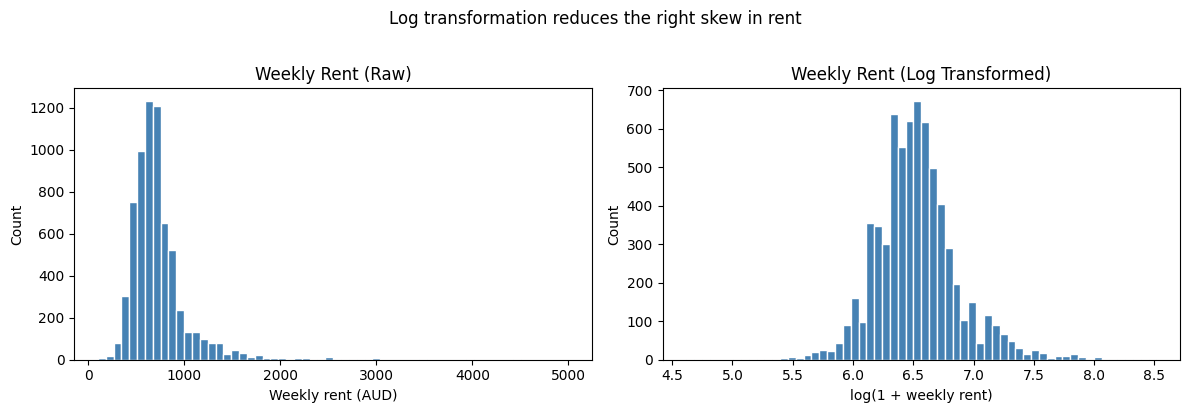

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["price_display"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Weekly Rent (Raw)")
axes[0].set_xlabel("Weekly rent (AUD)")
axes[0].set_ylabel("Count")

axes[1].hist(df["log_price"], bins=60, color="steelblue", edgecolor="white")
axes[1].set_title("Weekly Rent (Log Transformed)")
axes[1].set_xlabel("log(1 + weekly rent)")
axes[1].set_ylabel("Count")

plt.suptitle("Log transformation reduces the right skew in rent", y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Rent by Property Size

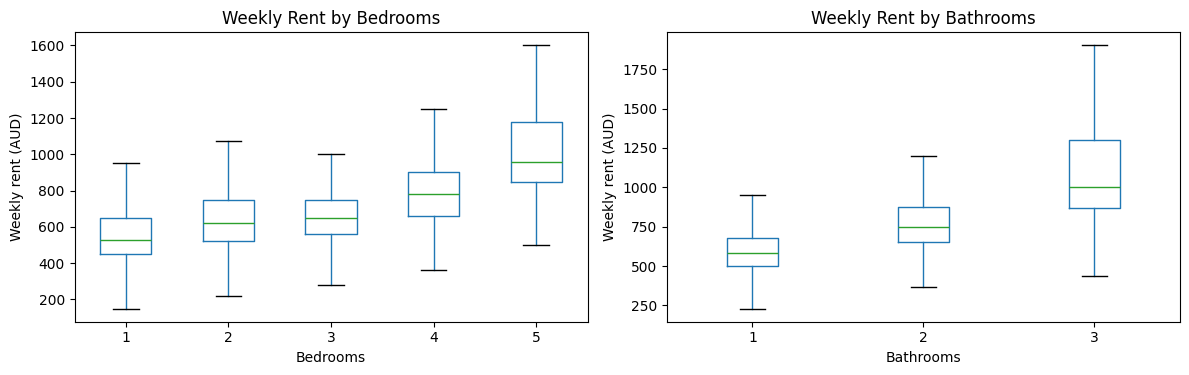

In [12]:
# Limit br / ba to Z = +2
plot_df = df[(df["bedrooms"] <= 5) & (df["bathrooms"] <= 3)].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df.boxplot(column="price_display", by="bedrooms", ax=axes[0], grid=False, showfliers=False)
plot_df.boxplot(column="price_display", by="bathrooms", ax=axes[1], grid=False, showfliers=False)

axes[0].set_title("Weekly Rent by Bedrooms")
axes[0].set_xlabel("Bedrooms")
axes[0].set_ylabel("Weekly rent (AUD)")

axes[1].set_title("Weekly Rent by Bathrooms")
axes[1].set_xlabel("Bathrooms")
axes[1].set_ylabel("Weekly rent (AUD)")

fig.suptitle("")
plt.tight_layout()
plt.show()

### 4.3 Rent by State

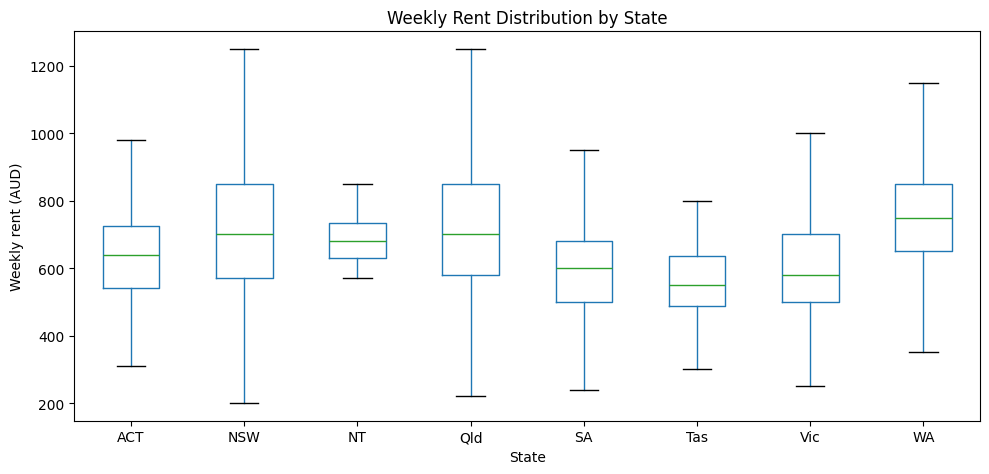

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

df.boxplot(column="price_display", by="state", ax=ax, grid=False, showfliers=False)

ax.set_title("Weekly Rent Distribution by State")
ax.set_xlabel("State")
ax.set_ylabel("Weekly rent (AUD)")

plt.suptitle("")
plt.tight_layout()
plt.show()

### 4.4 Rent by Amenity (Unadjusted)

This chart shows simple average rent differences by amenity. These are raw comparisons only. For example, listings with a pool may also be larger or located in more expensive areas. Later models control for size and location to see whether specific amenities still appear to matter after accounting for those factors.

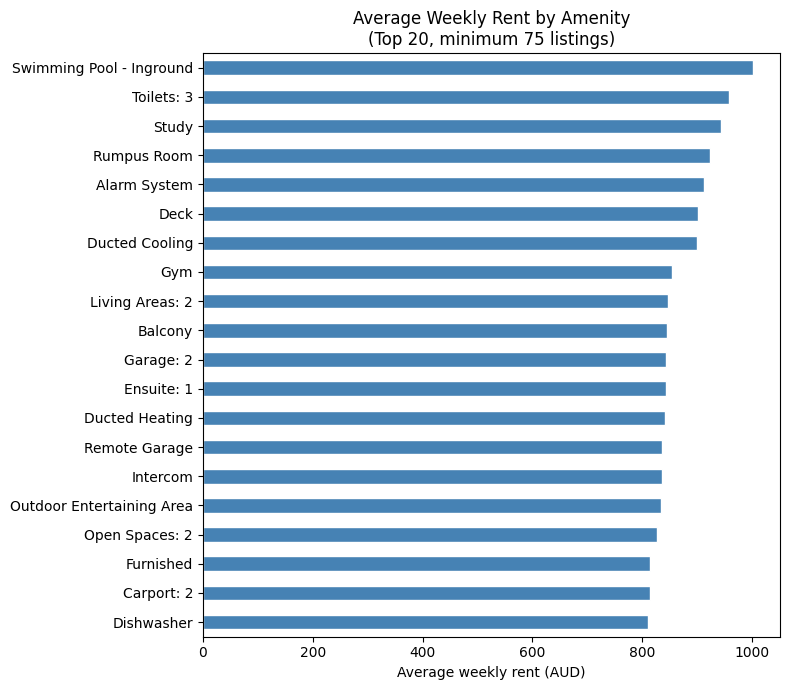

In [14]:
# Splits the amenity field into a list of amenities
amenity_lists = df["amenities"].str.split(",")

rows = []
# Generates a rent, ameninty pair
for i in range(len(df)):
    rent = df.loc[i, "price_display"]
    amenities = amenity_lists.iloc[i]

    for amenity in amenities:
        amenity = amenity.strip()

        if amenity != "":
            rows.append([amenity, rent])

amenity_df = pd.DataFrame(rows, columns=["amenity", "price_display"])

min_count = 75

amenity_stats = []
unique_amenities = amenity_df["amenity"].unique()

# Determines mean rent by unique amenity
for amenity in unique_amenities:
    rows_for_amenity = amenity_df[amenity_df["amenity"] == amenity]
    count = len(rows_for_amenity)

    if count >= min_count:
        avg_rent = rows_for_amenity["price_display"].mean()
        amenity_stats.append([amenity, count, avg_rent])

amenity_summary = pd.DataFrame( amenity_stats, columns=["amenity", "count", "avg_rent"])

amenity_summary = amenity_summary.sort_values(by="avg_rent", ascending=False)
amenity_summary = amenity_summary.head(20)

# Plots to 20 mean rent by amenity in descending order
fig, ax = plt.subplots(figsize=(8, 7))

amenity_summary.sort_values(by="avg_rent").plot( kind="barh", x="amenity",
    y="avg_rent", color="steelblue", edgecolor="white", ax=ax, legend=False)

ax.set_title(f"Average Weekly Rent by Amenity\n(Top 20, minimum {min_count} listings)")
ax.set_xlabel("Average weekly rent (AUD)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### 4.5 Distribution of Amenity Counts

Before incorporating amenity richness into the model, it is helpful to understand how many amenities listings typically contain. The chart below shows the distribution of amenity_count, defined as the total number of amenities listed for each property.

This provides context for later analysis in H5, where amenity_count is introduced as a variable capturing the general richness of a listing. Properties with more amenities may command higher rents simply because they are more fully featured overall, rather than because of any single amenity.

Understanding this distribution helps interpret the results of the H5 model, which separates the general premium associated with feature-rich listings from the effects of specific amenities.

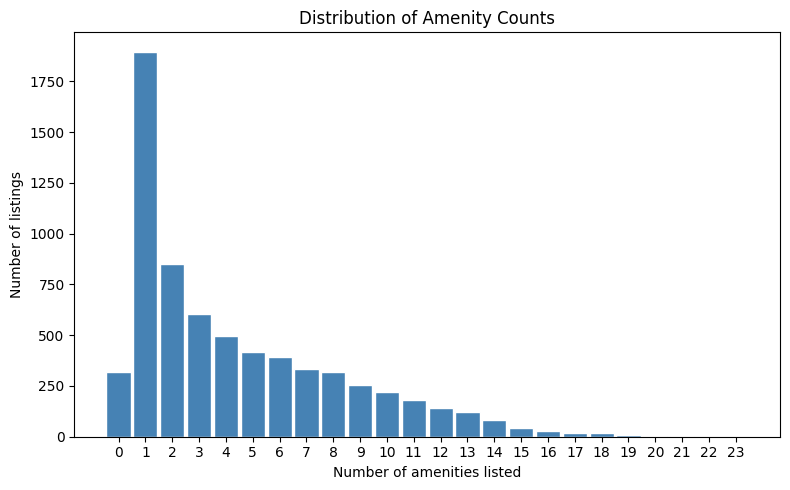

In [15]:
# 4.5 Distribution of amenity counts

amenity_lists = df["amenities"].str.split(",")

amenity_counts = []

# Count number of amenities per listing
for i in range(len(df)):
    amenities = amenity_lists.iloc[i]
    count = 0

    for amenity in amenities:
        amenity = amenity.strip()

        if amenity != "":
            count += 1

    amenity_counts.append(count)

# Plot histogram
max_count = max(amenity_counts)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(amenity_counts,bins=range(0, max_count + 2),align="left",color="steelblue",edgecolor="white",rwidth=0.9)

ax.set_title("Distribution of Amenity Counts")
ax.set_xlabel("Number of amenities listed")
ax.set_ylabel("Number of listings")
ax.set_xticks(range(0, max_count + 1))

plt.tight_layout()
plt.show()

## 5. Hypotheses

I built the model in stages, with each step testing whether a new group of variables 
improves predictive performance on a held-out test set.

**H1: Property fundamentals explain much of rent variation**
Baseline model using bedrooms, bathrooms, parking, and property type only.

**H2: Location adds important information**
Same properties can rent for very different prices depending on where they are. State 
and postcode are added to test how much location improves predictions.

**H3: Amenities improve the model further**
Amenity text is tokenized into individual dummy variables and added to test whether 
features like pools or air conditioning improve performance beyond size and location.

**H4: Which amenities are associated with higher rent?**
Lasso is used to identify which specific amenities retain meaningful coefficients after 
controlling for fundamentals and location, shrinking unimportant ones to zero.

**H5: Amenity richness adjustment**
An amenity_count variable is added to separate the general premium for feature-rich 
listings from the distinct effects of individual amenities.

## 6. Modeling

### H1: Fundamentals

The baseline model uses only bedrooms, bathrooms, parking spaces, and property type, 
no location, no amenities. This establishes how much rent can be explained by physical 
characteristics alone.

Ridge and Lasso are both tested with alpha tuned via 5-fold cross-validation. I expect 
bedrooms, bathrooms, and parking to be positively associated with rent, but the model 
to be limited without location information.

### Cross-Validated Model Fitting

The same fitting function is used at every stage (H1–H5) to ensure consistent tuning. 
For each candidate alpha, the training data is split into 5 folds, the model trains on 
4 and validates on the remaining 1, rotating until every fold has been used. The alpha 
with the lowest average MAE across folds is selected, then the model is refit on the 
full training set and evaluated once on the held-out test set.

In [16]:
# ------------------------------------------------------------
# Fit a regularized regression model using manual k-fold
# cross-validation to select the best alpha value.
#
# For each candidate alpha:
# 1. Split the training data into k folds
# 2. Train on k-1 folds and validate on the remaining fold
# 3. Compute the MAE for each fold
# 4. Average the fold MAEs
# 5. Keep the alpha with the lowest average CV MAE
#
# After selecting the best alpha, fit the final model on the
# full training set and evaluate it on the held-out test set.
# ------------------------------------------------------------
def fit_model_with_cv(model_type, X_train, y_train, X_test, y_test, alpha_values, kf, state_train):
    best_alpha = None
    best_cv_mae = None

    for alpha in alpha_values:
        fold_maes = []

        for train_index, val_index in kf.split(X_train, state_train):
            X_fold_train = X_train.iloc[train_index]
            X_fold_val = X_train.iloc[val_index]
            y_fold_train = y_train.iloc[train_index]
            y_fold_val = y_train.iloc[val_index]

            if model_type == "ridge":
                model = Ridge(alpha=alpha)
            elif model_type == "lasso":
                model = Lasso(alpha=alpha, max_iter=10000)

            model.fit(X_fold_train, y_fold_train)

            val_predictions = model.predict(X_fold_val)
            fold_mae = mean_absolute_error(y_fold_val, val_predictions)
            fold_maes.append(fold_mae)

        mean_cv_mae = np.mean(fold_maes)
        print(f"{model_type.title()} alpha={alpha}: CV MAE = {mean_cv_mae:.4f}")

        if best_cv_mae is None or mean_cv_mae < best_cv_mae:
            best_cv_mae = mean_cv_mae
            best_alpha = alpha

    if model_type == "ridge":
        best_model = Ridge(alpha=best_alpha)
    elif model_type == "lasso":
        best_model = Lasso(alpha=best_alpha, max_iter=10000)

    best_model.fit(X_train, y_train)

    # Predictions on log scale
    test_predictions = best_model.predict(X_test)

    # Metrics on log scale
    test_mae_log = mean_absolute_error(y_test, test_predictions)
    test_r2_log = r2_score(y_test, test_predictions)

    # Convert both actual and predicted values back to rent scale
    y_test_rent = np.expm1(y_test)
    test_predictions_rent = np.expm1(test_predictions)

    # Metrics on original rent scale
    test_mae_rent = mean_absolute_error(y_test_rent, test_predictions_rent)
    test_r2_rent = r2_score(y_test_rent, test_predictions_rent)

    return best_model, best_alpha, best_cv_mae, test_mae_log, test_r2_log, test_mae_rent, test_r2_rent


In [17]:
# Features for the fundamentals model 
X = df[["bedrooms", "bathrooms", "parking_spaces","propertyType"]].copy()
# Target for the fundamentals model
y = df["log_price"].copy()

# Convert propertyType into dummy columns with 0/1 values
X = pd.get_dummies(X, columns=["propertyType"])

# Generates a training set and test set. 
# Default value of test size is used (0.25).
# Random_state is fixed for reproducibility
# Sets are stratified by state to ensure equal distribution between sets.
X_train, X_test, y_train, y_test, state_train, state_test = train_test_split(X, y, df["state"], random_state=1, stratify=df["state"])

# Candidate alpha values
alpha_values = [0.001, 0.01, 0.1, 1, 10, 100]

# 5-fold cross-validation setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Training rows: 5067
Test rows: 1690


In [18]:
# Stores final results
results = []

# Ridge regression
best_ridge_model, best_ridge_alpha, best_ridge_cv_mae, ridge_mae_log, ridge_r2_log, ridge_mae_rent, ridge_r2_rent = fit_model_with_cv(
    "ridge", X_train, y_train, X_test, y_test, alpha_values, kf, state_train)

print(f"\nBest Ridge alpha: {best_ridge_alpha}\n")
results.append(["Ridge", ridge_mae_log, ridge_r2_log, ridge_mae_rent, ridge_r2_rent])

# Lasso regression
best_lasso_model, best_lasso_alpha, best_lasso_cv_mae, lasso_mae_log, lasso_r2_log, lasso_mae_rent, lasso_r2_rent = fit_model_with_cv(
    "lasso", X_train, y_train, X_test, y_test, alpha_values, kf, state_train)

print(f"\nBest Lasso alpha: {best_lasso_alpha}\n")
results.append(["Lasso", lasso_mae_log, lasso_r2_log, lasso_mae_rent, lasso_r2_rent])

# Results table
results_df = pd.DataFrame( results, columns=["model", "MAE_log", "R2_log", "MAE_rent", "R2_rent"])
display(results_df)

Ridge alpha=0.001: CV MAE = 0.1950
Ridge alpha=0.01: CV MAE = 0.1950
Ridge alpha=0.1: CV MAE = 0.1950
Ridge alpha=1: CV MAE = 0.1950
Ridge alpha=10: CV MAE = 0.1949
Ridge alpha=100: CV MAE = 0.1951

Best Ridge alpha: 10

Lasso alpha=0.001: CV MAE = 0.1951
Lasso alpha=0.01: CV MAE = 0.1964
Lasso alpha=0.1: CV MAE = 0.2371
Lasso alpha=1: CV MAE = 0.2538
Lasso alpha=10: CV MAE = 0.2538
Lasso alpha=100: CV MAE = 0.2538

Best Lasso alpha: 0.001



,model,MAE_log,R2_log,MAE_rent,R2_rent
0,Ridge,0.202248,0.357790,162.920139,0.237295
1,Lasso,0.202435,0.356516,163.086217,0.236272


### H1 Results

Ridge and Lasso perform almost identically here both achieve about **R2_log = 0.358** and 
**MAE_rent ≈ 163 AUD/week**. Property fundamentals explain about a third of rent variation, 
which is meaningful but limited. The model predictions are compressed toward the middle, 
cheap properties are overpredicted and expensive ones underpredicted, which points clearly 
to missing information. Location is the obvious next addition.

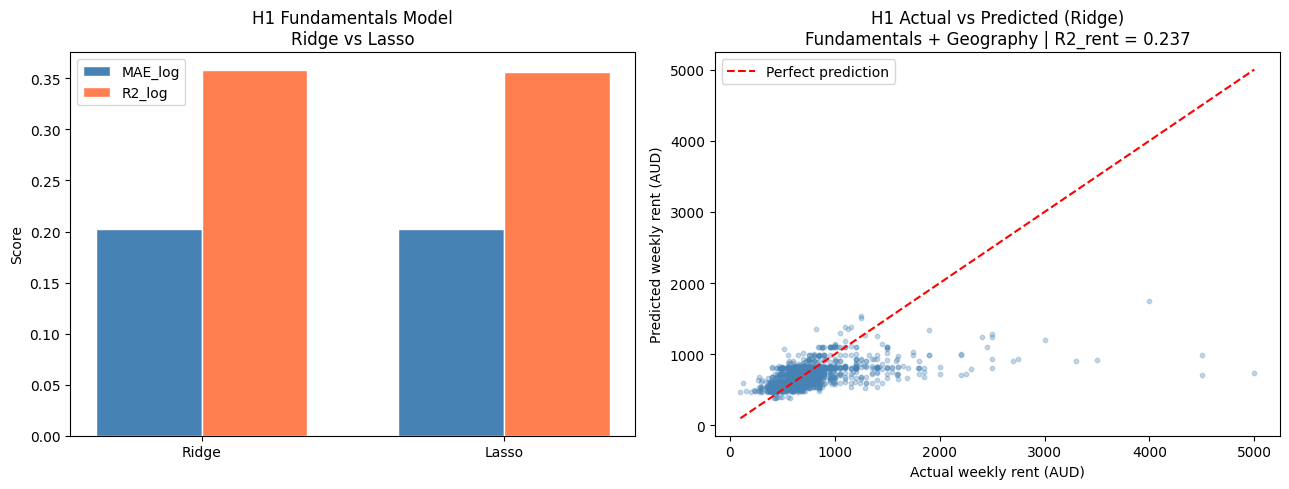

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ridge vs Lasso
plot_df = results_df.set_index("model")

models = plot_df.index.tolist()
x = np.arange(len(models))
width = 0.35

axes[0].bar( x - width / 2, plot_df["MAE_log"], width, label="MAE_log", color="steelblue", edgecolor="white" )

axes[0].bar( x + width / 2, plot_df["R2_log"], width, label="R2_log", color="coral", edgecolor="white" )
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title("H1 Fundamentals Model\nRidge vs Lasso")
axes[0].set_ylabel("Score")
axes[0].legend()

# Ridge performance
ridge_predictions = best_ridge_model.predict(X_test)

y_test_rent = np.expm1(y_test)
ridge_predictions_rent = np.expm1(ridge_predictions)

axes[1].scatter(y_test_rent, ridge_predictions_rent, alpha=0.3, color="steelblue", s=10)
axes[1].plot([y_test_rent.min(), y_test_rent.max()], [y_test_rent.min(), y_test_rent.max()],"r--", linewidth=1.5, label="Perfect prediction")

axes[1].set_title( "H1 Actual vs Predicted (Ridge)\n"
    f"Fundamentals + Geography | R2_rent = {ridge_r2_rent:.3f}")

axes[1].set_xlabel("Actual weekly rent (AUD)")
axes[1].set_ylabel("Predicted weekly rent (AUD)")
axes[1].legend()

plt.tight_layout()
plt.show()

### H1 Visualization Summary

The chart on the left shows that Ridge and Lasso perform almost identically when only the basic property features are used. This indicates that bedrooms, bathrooms, parking spaces, and property type contain useful predictive signal, but by themselves they explain only a limited share of the overall variation in rent.

The chart on the right shows that the Ridge model captures the general relationship between fundamentals and rent, but the predictions are compressed toward the middle of the rent distribution. Lower-rent listings are often predicted somewhat too high, while higher-rent listings are often predicted too low. This pattern suggests that important sources of variation, especially location and amenities, are still missing from the model.

### H2 Geography Adds Substantial Explanatory Power

State and postcode are added to test whether location explains rent variation beyond 
fundamentals. Postcode provides 1,093 neighborhood-level categories. Suburb will also 
be tested as a finer geographic layer (1,997 unique values) 


In [20]:
# Features now include fundamentals + geography (state, postcode, suburb)
X_geo = df[["bedrooms", "bathrooms", "parking_spaces", "propertyType",
            "state", "postcode", "suburb"]].copy()

# Convert categorical variables to dummy indicators
X_geo = pd.get_dummies(X_geo, columns=["propertyType", "state", "postcode", "suburb"])

# Recreate the same train/test split used in H1
X_train_geo, X_test_geo, y_train, y_test, state_train, state_test = train_test_split(
    X_geo, y, df["state"], random_state=1, stratify=df["state"])

print(f"Training rows: {len(X_train_geo)}")
print(f"Test rows: {len(X_test_geo)}")
print(f"Total features in H2: {X_geo.shape[1]}")

Training rows: 5067
Test rows: 1690
Total features in H2: 3109


In [21]:
# Features now include fundamentals + geography (state, postcode)
X_geo = df[["bedrooms", "bathrooms", "parking_spaces", "propertyType",
            "state", "postcode"]].copy()

# Convert categorical variables to dummy indicators
X_geo = pd.get_dummies(X_geo, columns=["propertyType", "state", "postcode"])

# Recreate the same train/test split used in H1
X_train_geo, X_test_geo, y_train, y_test, state_train, state_test = train_test_split(
    X_geo, y, df["state"], random_state=1, stratify=df["state"])

print(f"Training rows: {len(X_train_geo)}")
print(f"Test rows: {len(X_test_geo)}")
print(f"Total features in H2: {X_geo.shape[1]}")

results_geo = []

# Ridge regression
best_ridge_geo, best_ridge_alpha_geo, best_ridge_cv_mae_geo, ridge_mae_log_geo, ridge_r2_log_geo, ridge_mae_rent_geo, ridge_r2_rent_geo = fit_model_with_cv(
    "ridge", X_train_geo, y_train, X_test_geo, y_test, alpha_values, kf, state_train)

print(f"\nBest Ridge alpha (H2): {best_ridge_alpha_geo}\n")
results_geo.append(["Ridge", ridge_mae_log_geo, ridge_r2_log_geo, ridge_mae_rent_geo, ridge_r2_rent_geo])

# Lasso regression
best_lasso_geo, best_lasso_alpha_geo, best_lasso_cv_mae_geo, lasso_mae_log_geo, lasso_r2_log_geo, lasso_mae_rent_geo, lasso_r2_rent_geo = fit_model_with_cv(
    "lasso", X_train_geo, y_train, X_test_geo, y_test, alpha_values, kf, state_train)

print(f"\nBest Lasso alpha (H2): {best_lasso_alpha_geo}\n")
results_geo.append(["Lasso", lasso_mae_log_geo, lasso_r2_log_geo, lasso_mae_rent_geo, lasso_r2_rent_geo])

# Results table
results_h2_df = pd.DataFrame(results_geo, columns=["model", "MAE_log", "R2_log", "MAE_rent", "R2_rent"])
display(results_h2_df)

Training rows: 5067
Test rows: 1690
Total features in H2: 1114
Ridge alpha=0.001: CV MAE = 0.1334
Ridge alpha=0.01: CV MAE = 0.1333
Ridge alpha=0.1: CV MAE = 0.1324
Ridge alpha=1: CV MAE = 0.1325
Ridge alpha=10: CV MAE = 0.1563
Ridge alpha=100: CV MAE = 0.1785

Best Ridge alpha (H2): 0.1

Lasso alpha=0.001: CV MAE = 0.1792
Lasso alpha=0.01: CV MAE = 0.1916
Lasso alpha=0.1: CV MAE = 0.2371
Lasso alpha=1: CV MAE = 0.2538
Lasso alpha=10: CV MAE = 0.2538
Lasso alpha=100: CV MAE = 0.2538

Best Lasso alpha (H2): 0.001



,model,MAE_log,R2_log,MAE_rent,R2_rent
0,Ridge,0.138086,0.643514,115.564679,0.496778
1,Lasso,0.188489,0.442055,153.061483,0.311404


### H2 Results

Adding location produces the largest single jump in the entire analysis. Ridge selected 
**alpha = 0.1** and achieved **R2_log = 0.644** and **MAE_rent = 115.56 AUD/week**, 
up from 0.358 in H1. Lasso lagged significantly at **R2_log = 0.442**, consistent with 
geographic signal being spread across many correlated postcode indicators rather than 
concentrated in a sparse subset.

The gap between Ridge and Lasso here is the clearest signal in the project: location is 
not a handful of important postcodes, it's a broad, distributed effect across the entire 
geographic feature space, exactly the situation Ridge is designed for.

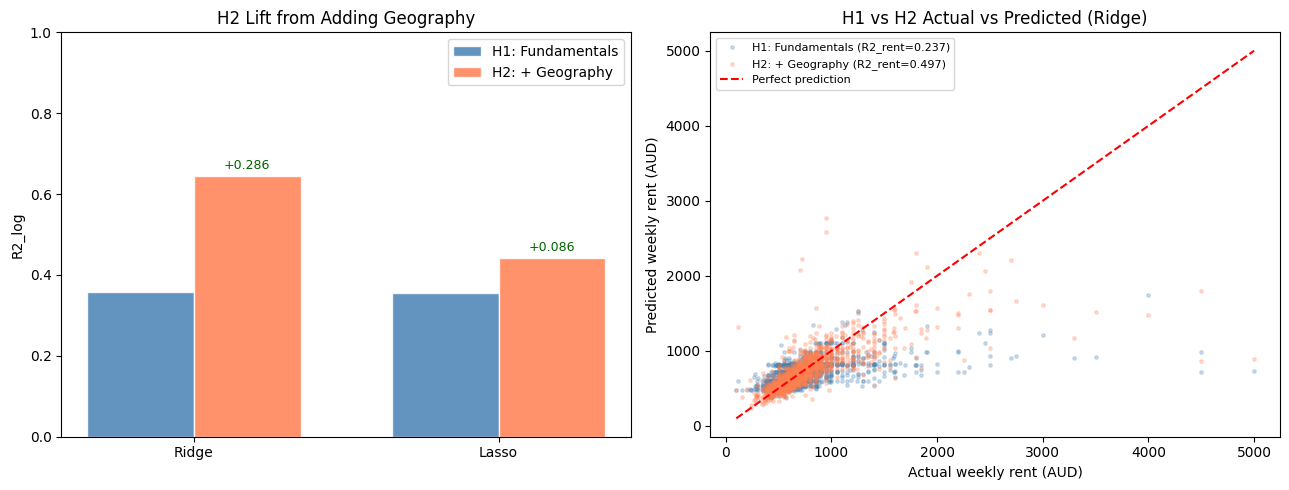

In [22]:
# --- Visualization: H1 vs H2 lift + actual vs predicted ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: H1 vs H2 R2 comparison
h1_r2 = results_df["R2_log"].values
h2_r2 = results_h2_df["R2_log"].values
models = ["Ridge", "Lasso"]
x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width / 2,h1_r2,width,label="H1: Fundamentals",
    color="steelblue",edgecolor="white",alpha=0.85)

axes[0].bar(x + width / 2,h2_r2,width,label="H2: + Geography",
            color="coral",edgecolor="white",alpha=0.85)

# Compute the improvement in R2 from H1 to H2
r2_lift = h2_r2 - h1_r2

# Add the improvement labels above the H2 bars
for i in range(len(r2_lift)):
    lift_value = r2_lift[i]
    x_position = x[i] + width / 2
    y_position = h2_r2[i] + 0.01
    label_text = f"+{lift_value:.3f}"
    axes[0].annotate(label_text,xy=(x_position, y_position),
        ha="center",va="bottom",fontsize=9,color="darkgreen")

axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title("H2 Lift from Adding Geography")
axes[0].set_ylabel("R2_log")
axes[0].legend()
axes[0].set_ylim(0, 1)

# Right: H1 vs H2 actual vs predicted (Ridge)
ridge_h1_predictions = best_ridge_model.predict(X_test)
ridge_h2_predictions = best_ridge_geo.predict(X_test_geo)

y_test_rent = np.expm1(y_test)
ridge_h1_predictions_rent = np.expm1(ridge_h1_predictions)
ridge_h2_predictions_rent = np.expm1(ridge_h2_predictions)

axes[1].scatter(y_test_rent,ridge_h1_predictions_rent,
    alpha=0.25,color="steelblue",s=6,label=f"H1: Fundamentals (R2_rent={ridge_r2_rent:.3f})")

axes[1].scatter(y_test_rent,ridge_h2_predictions_rent,
    alpha=0.25,color="coral",s=6,label=f"H2: + Geography (R2_rent={ridge_r2_rent_geo:.3f})")

axes[1].plot([y_test_rent.min(), y_test_rent.max()],[y_test_rent.min(), y_test_rent.max()],
    "r--",linewidth=1.5,label="Perfect prediction")

axes[1].set_title("H1 vs H2 Actual vs Predicted (Ridge)")
axes[1].set_xlabel("Actual weekly rent (AUD)")
axes[1].set_ylabel("Predicted weekly rent (AUD)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### H2 Visualization Summary

Ridge R2_log jumps from **0.358** in H1 to **0.644** in H2, the biggest gain in the 
entire project. Lasso also improves, from **0.371** to **0.442**, though it trails Ridge 
significantly. The scatter plot makes this concrete: H2 predictions track the diagonal 
much more closely than H1, meaning the model is capturing real structure rather than just 
predicting near the mean. Location is clearly the dominant driver of rent.

### H3: Amenities

Individual amenities are added to test whether they improve predictions beyond fundamentals 
and location. The amenities column is stored as comma-separated text, so each listing is 
split into individual features and converted to dummy variables.

Amenities are added after geography so any performance gain can be clearly attributed to 
them. I expect a modest improvement over H2 and for Lasso to be more competitive here, 
since amenity effects are more likely to be sparse than geographic ones.

In [23]:
# Add amenity features

# Clean the amenities text before creating dummy columns
def clean_amenity_text(text):
    items = text.split(",")
    cleaned_items = []
    for item in items:
        item = item.strip().lower()
        if item != "":
            cleaned_items.append(item)
    return ",".join(cleaned_items)

clean_amenities = df["amenities"].apply(clean_amenity_text)

# Create dummy columns from the cleaned text
amenity_dummies = clean_amenities.str.get_dummies(sep=",")

# Drop blank amenity column
amenity_dummies = amenity_dummies.loc[:, amenity_dummies.columns != ""]

# Combine the amenity columns with the feature set from H2
X_h3 = pd.concat([X_geo.copy(), amenity_dummies], axis=1)

y = df["log_price"].copy()

X_train_h3, X_test_h3, y_train, y_test, state_train, state_test = train_test_split(
    X_h3, y, df["state"], random_state=1, stratify=df["state"])

print(f"Training rows: {len(X_train_h3)}")
print(f"Test rows: {len(X_test_h3)}")
print(f"Total features in H3: {X_h3.shape[1]}")
print("Duplicate amenity columns:", amenity_dummies.columns.duplicated().sum())

Training rows: 5067
Test rows: 1690
Total features in H3: 1194
Duplicate amenity columns: 0


In [24]:
results_h3 = []

# Ridge regression
best_ridge_h3, best_ridge_alpha_h3, best_ridge_cv_mae_h3, ridge_mae_log_h3, ridge_r2_log_h3, ridge_mae_rent_h3, ridge_r2_rent_h3 = fit_model_with_cv(
    "ridge", X_train_h3, y_train, X_test_h3, y_test, alpha_values, kf, state_train)

print(f"\nBest Ridge alpha (H3): {best_ridge_alpha_h3}\n")
results_h3.append(["Ridge", ridge_mae_log_h3, ridge_r2_log_h3, ridge_mae_rent_h3, ridge_r2_rent_h3])

# Lasso regression
best_lasso_h3, best_lasso_alpha_h3, best_lasso_cv_mae_h3, lasso_mae_log_h3, lasso_r2_log_h3, lasso_mae_rent_h3, lasso_r2_rent_h3 = fit_model_with_cv(
    "lasso", X_train_h3, y_train, X_test_h3, y_test, alpha_values, kf, state_train)

print(f"\nBest Lasso alpha (H3): {best_lasso_alpha_h3}\n")
results_h3.append(["Lasso", lasso_mae_log_h3, lasso_r2_log_h3, lasso_mae_rent_h3, lasso_r2_rent_h3])

# Results table
results_h3_df = pd.DataFrame(results_h3, columns=["model", "MAE_log", "R2_log", "MAE_rent", "R2_rent"])
display(results_h3_df)

Ridge alpha=0.001: CV MAE = 0.1314
Ridge alpha=0.01: CV MAE = 0.1313
Ridge alpha=0.1: CV MAE = 0.1302
Ridge alpha=1: CV MAE = 0.1308
Ridge alpha=10: CV MAE = 0.1533
Ridge alpha=100: CV MAE = 0.1735

Best Ridge alpha (H3): 0.1

Lasso alpha=0.001: CV MAE = 0.1744
Lasso alpha=0.01: CV MAE = 0.1905
Lasso alpha=0.1: CV MAE = 0.2371
Lasso alpha=1: CV MAE = 0.2538
Lasso alpha=10: CV MAE = 0.2538
Lasso alpha=100: CV MAE = 0.2538

Best Lasso alpha (H3): 0.001



,model,MAE_log,R2_log,MAE_rent,R2_rent
0,Ridge,0.134540,0.659676,112.506100,0.513132
1,Lasso,0.180997,0.476817,147.291463,0.344403


### H3 Results

Amenities add a meaningful but modest improvement over H2. Ridge selected **alpha = 0.1** 
and achieved **R2_log = 0.660** and **MAE_rent = 112.51 AUD/week**, up from 0.644 in H2. 
Lasso improved to **R2_log = 0.477** but continues to trail Ridge significantly.

Contrary to expectations, Lasso did not close the gap with Ridge here. Amenity signal 
appears to be distributed across many features rather than concentrated in a sparse subset, 
which favors Ridge. The improvement over H2 is real but small, suggesting that much of the 
apparent amenity premium reflects feature-rich properties in already expensive locations 
rather than independent amenity effects.

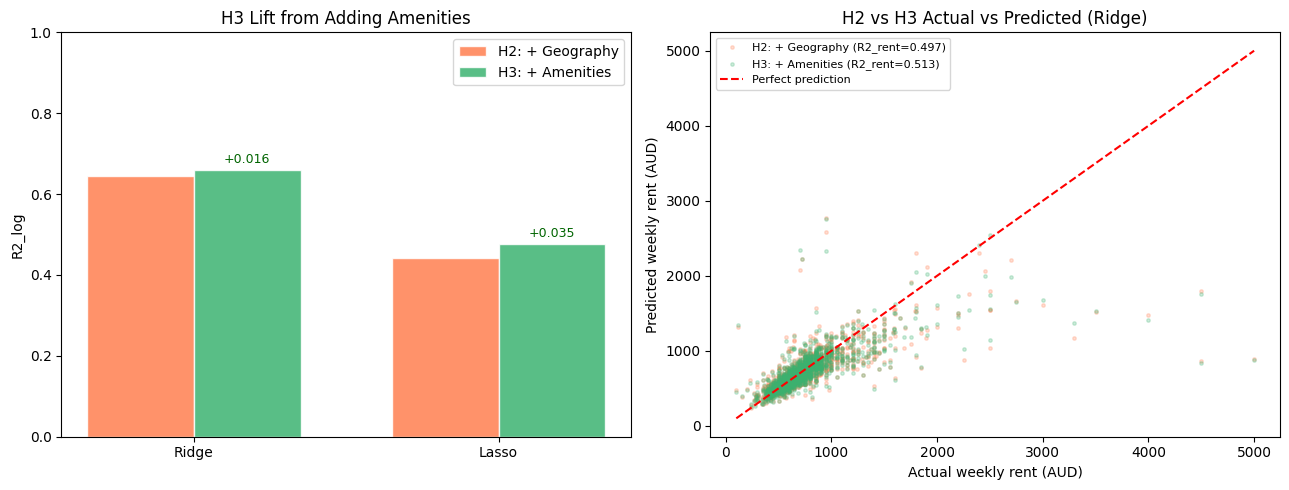

In [25]:
#H2 vs H3 lift + actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: H2 vs H3 R2 comparison
h2_r2 = results_h2_df["R2_log"].values
h3_r2 = results_h3_df["R2_log"].values
models = ["Ridge", "Lasso"]
x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width / 2,h2_r2,width,label="H2: + Geography",
    color="coral",edgecolor="white",alpha=0.85)

axes[0].bar(x + width / 2,h3_r2,width,label="H3: + Amenities",
            color="mediumseagreen",edgecolor="white",alpha=0.85)

# Compute the improvement in R2 from H2 to H3
r2_lift = h3_r2 - h2_r2

# Add the improvement labels above the H3 bars
for i in range(len(r2_lift)):
    lift_value = r2_lift[i]
    x_position = x[i] + width / 2
    y_position = h3_r2[i] + 0.01
    label_text = f"+{lift_value:.3f}"
    axes[0].annotate(label_text,xy=(x_position, y_position),
        ha="center",va="bottom",fontsize=9,color="darkgreen")

axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title("H3 Lift from Adding Amenities")
axes[0].set_ylabel("R2_log")
axes[0].legend()
axes[0].set_ylim(0, 1)

# Right: H2 vs H3 actual vs predicted (Ridge)
ridge_h2_predictions = best_ridge_geo.predict(X_test_geo)
ridge_h3_predictions = best_ridge_h3.predict(X_test_h3)

y_test_rent = np.expm1(y_test)
ridge_h2_predictions_rent = np.expm1(ridge_h2_predictions)
ridge_h3_predictions_rent = np.expm1(ridge_h3_predictions)

axes[1].scatter(y_test_rent,ridge_h2_predictions_rent,
    alpha=0.25,color="coral",s=6,label=f"H2: + Geography (R2_rent={ridge_r2_rent_geo:.3f})")

axes[1].scatter(y_test_rent,ridge_h3_predictions_rent,
    alpha=0.25,color="mediumseagreen",s=6,label=f"H3: + Amenities (R2_rent={ridge_r2_rent_h3:.3f})")

axes[1].plot([y_test_rent.min(), y_test_rent.max()],[y_test_rent.min(), y_test_rent.max()],
    "r--",linewidth=1.5,label="Perfect prediction")

axes[1].set_title("H2 vs H3 Actual vs Predicted (Ridge)")
axes[1].set_xlabel("Actual weekly rent (AUD)")
axes[1].set_ylabel("Predicted weekly rent (AUD)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### H3 Visualization Summary

Amenities produce a real but modest improvement. Ridge R2_log increases from **0.644** 
to **0.660** and the scatter plot shows a slight tightening around the diagonal, consistent 
with the small performance gain. Location is still doing most of the work. Amenities refine 
the predictions at the margins but don't change the overall story.

### H4: Amenity Effects

H3 showed amenities improve the model overall. H4 looks at which specific amenities drive 
that signal. Lasso is used here rather than Ridge because it can shrink weaker amenity 
coefficients to zero, producing a cleaner list of features that actually matter.

Coefficients are converted from log scale to approximate percentage effects using 
100 x (e^β - 1), so a coefficient of 0.05 reads as roughly +5% predicted rent holding 
everything else fixed. Positive coefficients indicate amenities associated with higher 
rent; negative ones indicate the opposite.

I expect premium features like pools and parking upgrades to show positive associations, 
while very common amenities may show near-zero coefficients since they don't differentiate 
higher-priced properties.

In [26]:
# H4: Extract amenity coefficients from the H3 Lasso model

# Put feature names and coefficients together in one table
coef_df = pd.DataFrame({"feature": X_train_h3.columns, "coef_log": best_lasso_h3.coef_})

# Keep only amenity features (removes all the features from h3 that existed in h2)
h2_features = set(X_geo.columns)
amenity_df = coef_df[~coef_df["feature"].isin(h2_features)].copy()

# Convert log-scale coefficients to approximate percent effects
amenity_df["pct_effect"] = (np.exp(amenity_df["coef_log"]) - 1) * 100

# Clean up names for display
amenity_df["amenity"] = amenity_df["feature"]

# Split into positive, negative, and zero coefficients
premium_amenities = amenity_df[amenity_df["coef_log"] > 0].copy()
discount_amenities = amenity_df[amenity_df["coef_log"] < 0].copy()
zeroed_amenities = amenity_df[amenity_df["coef_log"] == 0].copy()

# Sort for easier reading
premium_amenities = premium_amenities.sort_values(by="coef_log", ascending=False)
discount_amenities = discount_amenities.sort_values(by="coef_log", ascending=True)

# Print summary
retained_count = len(amenity_df[amenity_df["coef_log"] != 0])
zeroed_count = len(zeroed_amenities)

print(f"Amenities retained by Lasso: {retained_count}")
print(f"Amenities zeroed out by Lasso: {zeroed_count}")

print("\nTop premium amenities:")
display(premium_amenities[["amenity", "coef_log", "pct_effect"]].head(10).reset_index(drop=True))

print("\nTop discount amenities:")
display(discount_amenities[["amenity", "coef_log", "pct_effect"]].head(10).reset_index(drop=True))

Amenities retained by Lasso: 25
Amenities zeroed out by Lasso: 55

Top premium amenities:


,amenity,coef_log,pct_effect
0,swimming pool - inground,0.118187,12.545442
1,deck,0.055550,5.712160
2,study,0.041781,4.266614
3,floorboards,0.039353,4.013778
4,furnished,0.036188,3.685034
5,balcony,0.035887,3.653898
6,ducted cooling,0.035131,3.575542
7,intercom,0.034360,3.495751
8,outdoor entertaining area,0.033975,3.455836
9,gym,0.024475,2.477717



Top discount amenities:


,amenity,coef_log,pct_effect
0,fully fenced,-0.051639,-5.032803
1,toilets: 2,-0.027879,-2.749386
2,air conditioning,-0.016148,-1.601877
3,ensuite: 1,-0.014546,-1.444029
4,toilets: 1,-0.013735,-1.364123
5,split-system air conditioning,-0.012627,-1.254765
6,evaporative cooling,-0.011612,-1.154511
7,secure parking,-0.005072,-0.505906
8,remote garage,-0.003009,-0.300442


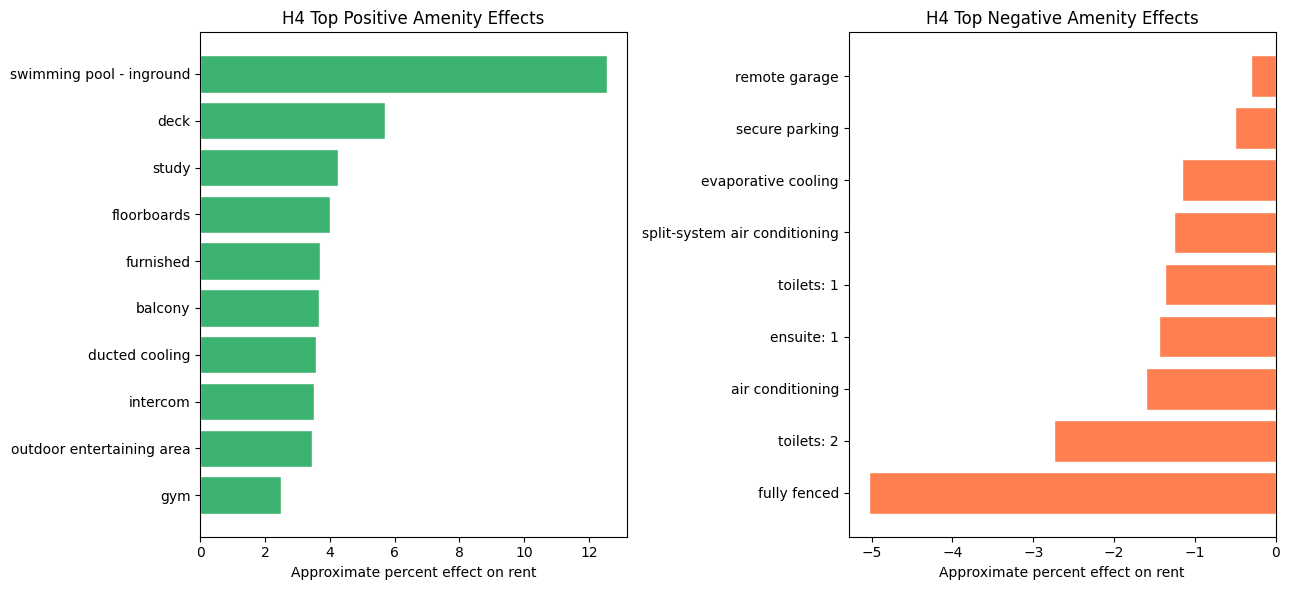

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Top positive amenity effects
top_positive = premium_amenities.head(10).copy()
top_positive = top_positive.sort_values(by="pct_effect", ascending=True)

axes[0].barh(top_positive["amenity"],top_positive["pct_effect"],
    color="mediumseagreen",edgecolor="white")

axes[0].set_title("H4 Top Positive Amenity Effects")
axes[0].set_xlabel("Approximate percent effect on rent")
axes[0].set_ylabel("")

# Top negative amenity effects
top_negative = discount_amenities.head(10).copy()
top_negative = top_negative.sort_values(by="pct_effect", ascending=True)

axes[1].barh(top_negative["amenity"],top_negative["pct_effect"],color="coral",edgecolor="white")

axes[1].set_title("H4 Top Negative Amenity Effects")
axes[1].set_xlabel("Approximate percent effect on rent")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### H4 Results

Lasso retained 25 amenities with non-zero coefficients and zeroed out 55, suggesting most 
amenities don't add meaningful signal once location and fundamentals are controlled for.

Among those that do matter, inground swimming pools show the strongest premium at roughly 
**+12.5%** predicted rent, followed by decks **(+5.7%)**, studies **(+4.3%)**, and 
floorboards **(+4.0%)**. Furnished listings and balconies also show modest positive effects.

On the negative side, fully fenced **(−5.0%)** shows the largest discount, followed by 
toilets: 2 **(−2.7%)** and air conditioning **(−1.6%)**. These negative coefficients are 
somewhat counterintuitive but make sense in context. After controlling for location, these 
features may be more common in lower-priced suburban or regional properties than in premium 
city listings.

### H5: Amenity Richness Adjustment

H4 showed which amenities are associated with higher rent, but many amenities appear 
together. A property with a pool often also has a deck, outdoor entertaining, and ducted 
cooling. So the question becomes: are the premiums in H4 driven by specific features, or 
just by properties being more feature-rich overall?

To test this, amenity_count is added to the model representing the total number of amenities 
listed per property. This lets the model separate two effects: the general premium for 
feature-rich listings, and the distinct value of specific amenities above and beyond that 
general richness. Amenities that retain non-zero coefficients after adding amenity_count 
are the ones whose value appears genuinely distinct.

In [28]:
# H5: Add amenity count to the H3 feature set

# Count the number of amenities listed for each property
amenity_count = []
for text in df["amenities"]:
    items = text.split(",")
    count = 0
    for item in items:
        item = item.strip()
        if item != "":
            count += 1
    amenity_count.append(count)

# Start with the H3 feature set and add amenity_count
X_h5 = X_h3.copy()
X_h5["amenity_count"] = amenity_count

X_train_h5, X_test_h5, y_train, y_test, state_train, state_test = train_test_split(
    X_h5, y, df["state"], random_state=1, stratify=df["state"])

print(f"Training rows: {len(X_train_h5)}")
print(f"Test rows: {len(X_test_h5)}")
print(f"Total features in H5: {X_h5.shape[1]}")

Training rows: 5067
Test rows: 1690
Total features in H5: 1195


In [29]:
results_h5 = []

# Ridge regression
best_ridge_h5, best_ridge_alpha_h5, best_ridge_cv_mae_h5, ridge_mae_log_h5, ridge_r2_log_h5, ridge_mae_rent_h5, ridge_r2_rent_h5 = fit_model_with_cv(
    "ridge", X_train_h5, y_train, X_test_h5, y_test, alpha_values, kf, state_train)

print(f"\nBest Ridge alpha (H5): {best_ridge_alpha_h5}\n")
results_h5.append(["Ridge", ridge_mae_log_h5, ridge_r2_log_h5, ridge_mae_rent_h5, ridge_r2_rent_h5])

# Lasso regression
best_lasso_h5, best_lasso_alpha_h5, best_lasso_cv_mae_h5, lasso_mae_log_h5, lasso_r2_log_h5, lasso_mae_rent_h5, lasso_r2_rent_h5 = fit_model_with_cv(
    "lasso", X_train_h5, y_train, X_test_h5, y_test, alpha_values, kf, state_train)

print(f"\nBest Lasso alpha (H5): {best_lasso_alpha_h5}\n")
results_h5.append(["Lasso", lasso_mae_log_h5, lasso_r2_log_h5, lasso_mae_rent_h5, lasso_r2_rent_h5])

# Results table
results_h5_df = pd.DataFrame(results_h5, columns=["model", "MAE_log", "R2_log", "MAE_rent", "R2_rent"])
display(results_h5_df)

Ridge alpha=0.001: CV MAE = 0.1315
Ridge alpha=0.01: CV MAE = 0.1313
Ridge alpha=0.1: CV MAE = 0.1302
Ridge alpha=1: CV MAE = 0.1308
Ridge alpha=10: CV MAE = 0.1532
Ridge alpha=100: CV MAE = 0.1734

Best Ridge alpha (H5): 0.1

Lasso alpha=0.001: CV MAE = 0.1744
Lasso alpha=0.01: CV MAE = 0.1904
Lasso alpha=0.1: CV MAE = 0.2331
Lasso alpha=1: CV MAE = 0.2538
Lasso alpha=10: CV MAE = 0.2538
Lasso alpha=100: CV MAE = 0.2538

Best Lasso alpha (H5): 0.001



,model,MAE_log,R2_log,MAE_rent,R2_rent
0,Ridge,0.134507,0.659872,112.488299,0.513319
1,Lasso,0.180593,0.478217,147.016699,0.345494


### H5 Results

Ridge selected **alpha = 0.1** and achieved **R2_log = 0.660** and **MAE_rent = 112.49 
AUD/week**, essentially identical to H3. The improvement from adding amenity_count is 
negligible in terms of predictive performance.

The more interesting result is what happens to individual amenity coefficients. Once 
amenity_count is in the model, the general premium for feature-rich listings is absorbed 
by that variable, leaving individual amenity coefficients to reflect only what is distinct 
about that specific feature. Amenities that shrink or zero out in H5 were likely just 
proxies for overall listing richness in H4. Those that retain meaningful coefficients 
represent features with genuine independent value.

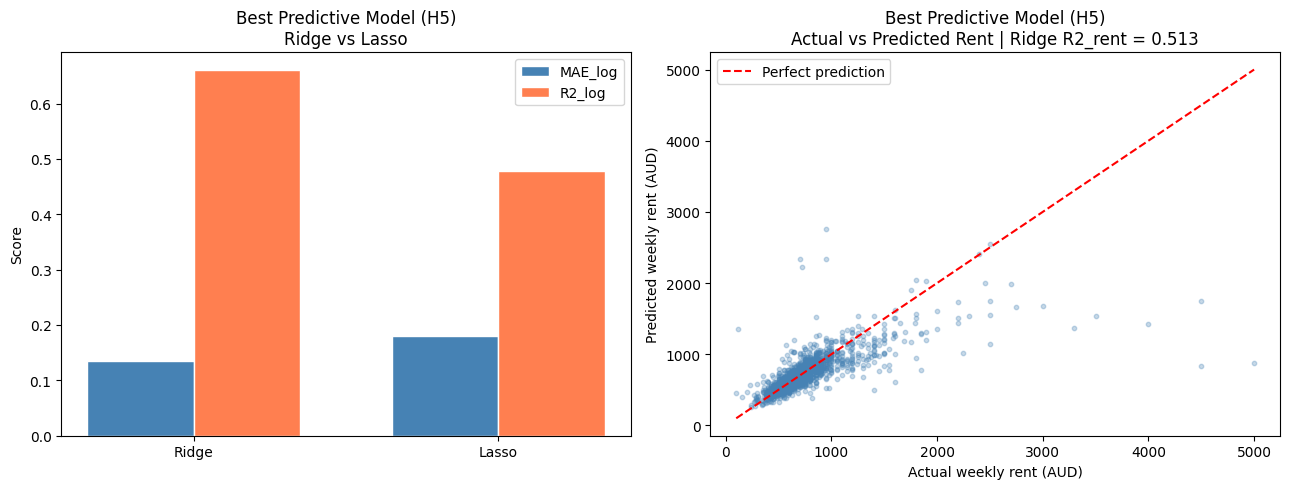

In [30]:
# Recreates plots from H1 for H5

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ridge vs Lasso
plot_df = results_h5_df.set_index("model")

models = plot_df.index.tolist()
x = np.arange(len(models))
width = 0.35

axes[0].bar( x - width / 2, plot_df["MAE_log"], width, label="MAE_log", color="steelblue", edgecolor="white" )

axes[0].bar( x + width / 2, plot_df["R2_log"], width, label="R2_log", color="coral", edgecolor="white" )
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title("Best Predictive Model (H5)\nRidge vs Lasso")
axes[0].set_ylabel("Score")
axes[0].legend()

# Ridge performance
ridge_h5_predictions = best_ridge_h5.predict(X_test_h5)

y_test_rent = np.expm1(y_test)
ridge_h5_predictions_rent = np.expm1(ridge_h5_predictions)

axes[1].scatter(y_test_rent, ridge_h5_predictions_rent, alpha=0.3, color="steelblue", s=10)
axes[1].plot([y_test_rent.min(), y_test_rent.max()], [y_test_rent.min(), y_test_rent.max()],"r--", linewidth=1.5, label="Perfect prediction")

axes[1].set_title( "Best Predictive Model (H5)\n"
    f"Actual vs Predicted Rent | Ridge R2_rent = {ridge_r2_rent_h5:.3f}")

axes[1].set_xlabel("Actual weekly rent (AUD)")
axes[1].set_ylabel("Predicted weekly rent (AUD)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [31]:
# H5: Extract amenity_count and compare H5 amenity effects to H4

amenity_df_h4 = amenity_df.copy()

# Put H5 feature names and coefficients into one table
coef_df_h5 = pd.DataFrame({"feature": X_train_h5.columns,"coef_log_h5": best_lasso_h5.coef_})

# Convert H5 coefficients to approximate percent effects
coef_df_h5["pct_effect_h5"] = (np.exp(coef_df_h5["coef_log_h5"]) - 1) * 100

# Amenity count effect
amenity_count_row = coef_df_h5[coef_df_h5["feature"] == "amenity_count"].copy()

print("Amenity count effect:")
display(amenity_count_row[["feature", "coef_log_h5", "pct_effect_h5"]].reset_index(drop=True))

# Individual H5 amenity effects
h2_features = set(X_geo.columns)
amenity_df_h5 = coef_df_h5[(~coef_df_h5["feature"].isin(h2_features)) &(coef_df_h5["feature"] != "amenity_count")].copy()
amenity_df_h5["amenity"] = amenity_df_h5["feature"]

# Bring in the H4 percent effects for comparison
h4_compare = amenity_df_h4[["amenity", "pct_effect"]].copy()
h4_compare = h4_compare.rename(columns={"pct_effect": "pct_effect_h4"})
amenity_compare = pd.merge(amenity_df_h5, h4_compare,on="amenity",how="left")

# Compute the change from H4 to H5
amenity_compare["delta"] = (amenity_compare["pct_effect_h5"] - amenity_compare["pct_effect_h4"])

# Split into positive, negative, and zero H5 coefficients
premium_amenities_h5 = amenity_compare[amenity_compare["coef_log_h5"] > 0].copy()
discount_amenities_h5 = amenity_compare[amenity_compare["coef_log_h5"] < 0].copy()
zeroed_amenities_h5 = amenity_compare[amenity_compare["coef_log_h5"] == 0].copy()
premium_amenities_h5 = premium_amenities_h5.sort_values(by="coef_log_h5", ascending=False)
discount_amenities_h5 = discount_amenities_h5.sort_values(by="coef_log_h5", ascending=True)

# Print summary
retained_count_h5 = len(amenity_compare[amenity_compare["coef_log_h5"] != 0])
zeroed_count_h5 = len(zeroed_amenities_h5)

print(f"\nAmenities retained by Lasso after adding amenity_count: {retained_count_h5}")
print(f"Amenities zeroed out by Lasso after adding amenity_count: {zeroed_count_h5}")

print("\nTop premium amenities:")
display(premium_amenities_h5[["amenity", "pct_effect_h4", "pct_effect_h5", "delta"]].head(10).reset_index(drop=True))

print("\nTop discount amenities:")
display(discount_amenities_h5[["amenity", "pct_effect_h4", "pct_effect_h5", "delta"]].head(10).reset_index(drop=True))

Amenity count effect:


,feature,coef_log_h5,pct_effect_h5
0,amenity_count,0.008701,0.873935



Amenities retained by Lasso after adding amenity_count: 28
Amenities zeroed out by Lasso after adding amenity_count: 52

Top premium amenities:


,amenity,pct_effect_h4,pct_effect_h5,delta
0,swimming pool - inground,12.545442,11.622196,-0.923246
1,deck,5.712160,4.674443,-1.037717
2,floorboards,4.013778,3.035046,-0.978732
3,study,4.266614,3.019313,-1.247301
4,furnished,3.685034,2.812922,-0.872112
5,balcony,3.653898,2.634071,-1.019827
6,intercom,3.495751,2.482356,-1.013395
7,outdoor entertaining area,3.455836,2.398489,-1.057347
8,ducted cooling,3.575542,1.767690,-1.807852
9,courtyard,2.254887,1.304109,-0.950778



Top discount amenities:


,amenity,pct_effect_h4,pct_effect_h5,delta
0,fully fenced,-5.032803,-6.169301,-1.136498
1,toilets: 2,-2.749386,-3.747525,-0.998139
2,split-system air conditioning,-1.254765,-2.641822,-1.387057
3,air conditioning,-1.601877,-2.559569,-0.957691
4,toilets: 1,-1.364123,-2.526510,-1.162387
5,evaporative cooling,-1.154511,-2.493044,-1.338532
6,ensuite: 1,-1.444029,-2.476690,-1.032661
7,secure parking,-0.505906,-1.578914,-1.073008
8,remote garage,-0.300442,-1.498934,-1.198492
9,broadband internet available,0.000000,-0.804901,-0.804901


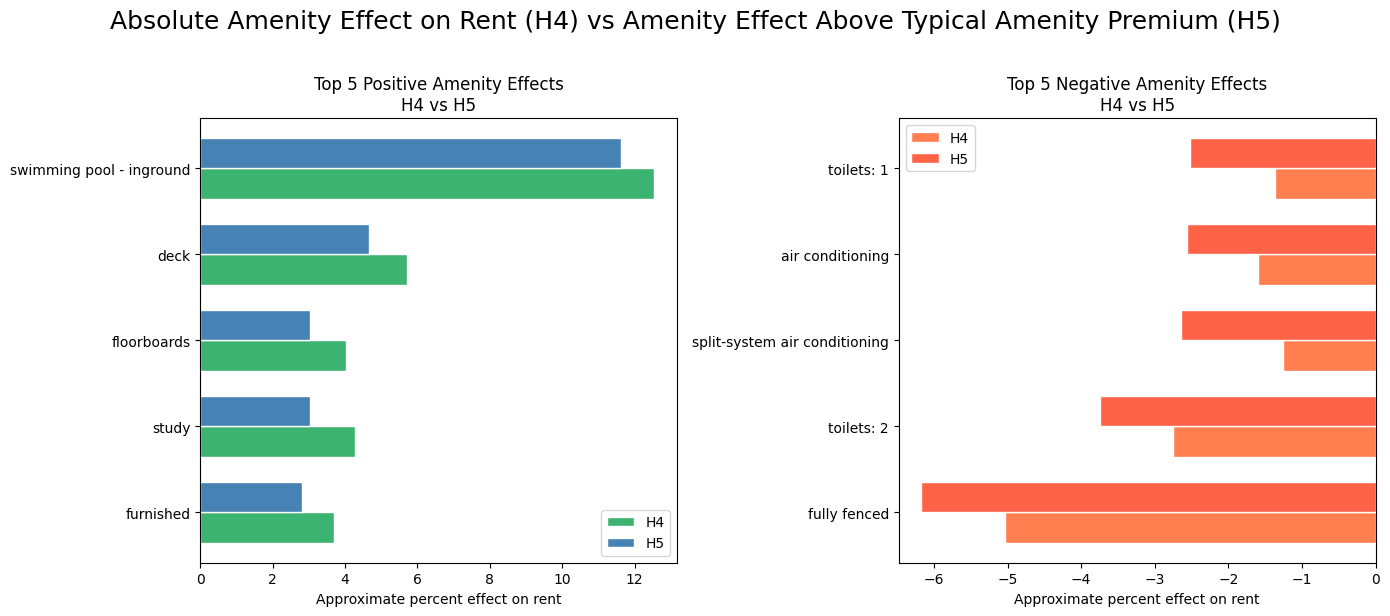

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plt.suptitle('Absolute Amenity Effect on Rent (H4) vs Amenity Effect Above Typical Amenity Premium (H5)',fontsize=18,y=1.02)

# Top 5 positive amenities: H4 vs H5
top_positive_compare = premium_amenities_h5.head(5).copy()
top_positive_compare = top_positive_compare.sort_values(by="pct_effect_h5", ascending=True)

y_pos = np.arange(len(top_positive_compare))
bar_height = 0.35

axes[0].barh(y_pos - bar_height / 2,top_positive_compare["pct_effect_h4"],height=bar_height,
    color="mediumseagreen",edgecolor="white",label="H4")

axes[0].barh(y_pos + bar_height / 2,top_positive_compare["pct_effect_h5"],
    height=bar_height,color="steelblue",edgecolor="white",label="H5")

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(top_positive_compare["amenity"])
axes[0].set_title("Top 5 Positive Amenity Effects\nH4 vs H5")
axes[0].set_xlabel("Approximate percent effect on rent")
axes[0].set_ylabel("")
axes[0].legend()

# Top 5 negative amenities: H4 vs H5
top_negative_compare = discount_amenities_h5.head(5).copy()
top_negative_compare = top_negative_compare.sort_values(by="pct_effect_h5", ascending=True)

y_neg = np.arange(len(top_negative_compare))

axes[1].barh(y_neg - bar_height / 2,top_negative_compare["pct_effect_h4"],
    height=bar_height,color="coral",edgecolor="white",label="H4")

axes[1].barh(y_neg + bar_height / 2,top_negative_compare["pct_effect_h5"],
    height=bar_height,color="tomato",edgecolor="white",label="H5")

axes[1].set_yticks(y_neg)
axes[1].set_yticklabels(top_negative_compare["amenity"])
axes[1].set_title("Top 5 Negative Amenity Effects\nH4 vs H5")
axes[1].set_xlabel("Approximate percent effect on rent")
axes[1].set_ylabel("")
axes[1].legend()

plt.tight_layout()
plt.show()

### H5 Summary

Adding amenity_count captures a general richness premium of about **+0.87% per additional 
listed amenity**. Once that is in the model, individual amenity coefficients reflect only 
what is distinct about that specific feature above and beyond simply having more amenities.

The pattern is consistent: positive premiums shrink and negative discounts grow. Features 
like pools and decks retain meaningful positive associations, confirming their value is 
genuine and not just a proxy for listing richness. Features like fully fenced and 
split-system air conditioning become more negative, suggesting they are common in 
lower-priced properties and carry even less independent value than H4 implied.

Overall, rental price depends on both amenity quantity and amenity composition. There is 
a modest premium for feature-rich listings, but certain amenities still carry distinct 
associations with rent after controlling for that general effect.

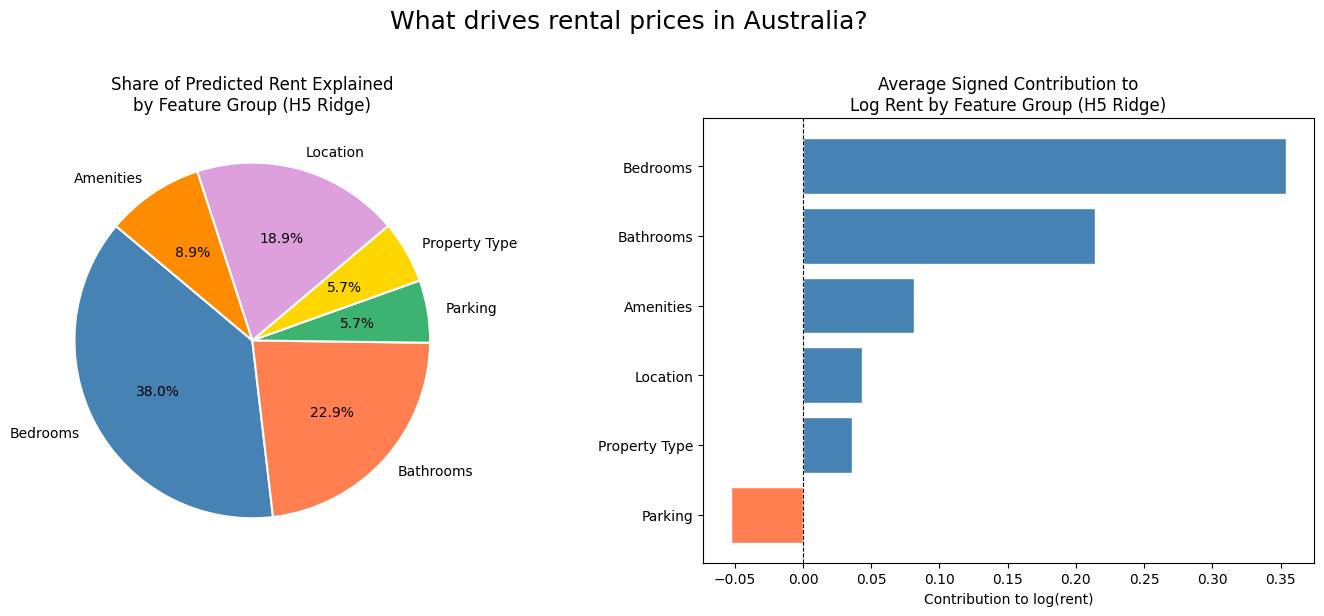

In [33]:
# Get the coefficients from the H5 Ridge model as a labeled Series
# This pairs each coefficient with its feature name
coefs = pd.Series(best_ridge_h5.coef_, index=X_train_h5.columns)

# Multiply each feature value by its coefficient for every listing in the test set
# The result is a table of the same shape as X_test_h5, but instead of raw feature
# values, each cell contains how much that feature contributed to the predicted rent
contributions = X_test_h5.copy() * coefs

# Assign each feature to a group
# We'll use this to sum up contributions by group later
feature_groups = {}
for col in X_test_h5.columns:
    if col == 'bedrooms':
        feature_groups[col] = 'Bedrooms'
    elif col == 'bathrooms':
        feature_groups[col] = 'Bathrooms'
    elif col == 'parking_spaces':
        feature_groups[col] = 'Parking'
    elif col.startswith('propertyType_'):
        feature_groups[col] = 'Property Type'
    elif col.startswith('state_') or col.startswith('postcode_'):
        feature_groups[col] = 'Location'
    elif col == 'amenity_count':
        feature_groups[col] = 'Amenities'
    else:
        feature_groups[col] = 'Amenities'

# Get the unique group names
groups = ['Bedrooms', 'Bathrooms', 'Parking', 'Property Type', 'Location', 'Amenities']

# For each group, find all features belonging to it and sum their contributions
# This gives us one column per group showing the total contribution for each listing
group_contributions = pd.DataFrame()
for group in groups:
    # Find all features belonging to this group
    group_features = [col for col in X_test_h5.columns if feature_groups[col] == group]
    # Sum contributions across all features in the group for each listing
    group_contributions[group] = contributions[group_features].sum(axis=1)

# Compute the average absolute contribution per group across all listings
# Absolute value is used so that positive and negative contributions
# within a group don't cancel each other out
mean_abs = group_contributions.abs().mean()

# Compute the average signed contribution per group
# This shows direction: positive means the group pushes rent up on average
mean_signed = group_contributions.mean().sort_values()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['steelblue', 'coral', 'mediumseagreen', 'gold', 'plum', 'darkorange']

# Pie chart: share of total explained variation by group (intercept excluded)
axes[0].pie(
    mean_abs,
    labels=mean_abs.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Share of Predicted Rent Explained\nby Feature Group (H5 Ridge)')

# Bar chart: average signed contribution by group
# Coral = negative contribution, steelblue = positive
bar_colors = ['coral' if v < 0 else 'steelblue' for v in mean_signed]
axes[1].barh(mean_signed.index, mean_signed.values, color=bar_colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Average Signed Contribution to\nLog Rent by Feature Group (H5 Ridge)')
axes[1].set_xlabel('Contribution to log(rent)')

plt.suptitle('What drives rental prices in Australia?', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### H5 Visualization: What Drives Rental Prices?

To understand the relative contribution of each feature group, I decomposed the H5 Ridge 
model predictions into components. For each listing in the test set, each feature's 
contribution is calculated as its value multiplied by its coefficient. Contributions are 
then summed by group (Bedrooms, Bathrooms, Parking, Property Type, Location, Amenities) 
and averaged across all listings. The pie chart shows each group's share of the total 
absolute contribution, while the bar chart shows the average signed contribution to 
log rent, positive means the group pushes rent up on average, negative means it pulls 
it down.

The results are striking. Bedrooms dominate at **38%** of total explained variation, 
followed by Bathrooms at **23%**. Location accounts for **19%** despite having over 
1,000 postcode indicators, reflecting how regularization compresses many small geographic 
effects. Amenities contribute **9%** and Parking and Property Type each add about **6%**.

The bar chart adds an important nuance: parking has a negative average signed contribution, 
meaning that after controlling for everything else, additional parking spaces are associated 
with slightly lower predicted rent. This likely reflects that high-parking properties tend 
to be in suburban or regional areas where rents are lower to begin with.

# 7. Conclusions and Summary of Findings

This analysis examined the Australian Rental Market Data 2026 dataset to understand what 
drives weekly rental prices, building the model incrementally and evaluating each stage 
on a held-out test set.

### The Incremental Model Story

| Stage | R2_log | MAE_log | R2_rent | MAE_rent | Key Finding |
|---|---:|---:|---:|---:|---|
| H1: Fundamentals | 0.358 | 0.202 | 0.237 | 162.92 | Property size explains some rent variation but the model is limited without location. |
| H2: + Geography | 0.644 | 0.138 | 0.497 | 115.56 | Location is the dominant driver of rent and produces the largest single improvement. |
| H3: + Amenities | 0.660 | 0.135 | 0.513 | 112.51 | Amenities add a modest but consistent improvement beyond fundamentals and geography. |
| H5: + Amenity Richness | 0.660 | 0.135 | 0.513 | 112.49 | Amenity count captures a general richness premium; individual effects shrink but persist. |

The jump from H1 to H2 is the clearest result in the project. Location explains far more 
than physical characteristics alone, and that gap never closes regardless of what else is 
added to the model.

### Final Model Performance

The final H5 Ridge model includes property fundamentals, geographic indicators, individual 
amenity dummies, and overall amenity richness. It achieves:

- **R2_log = 0.660**, explaining about 66% of variation in log weekly rent
- **MAE_rent = 112.49 AUD/week**, meaning predictions are off by about 112 AUD/week on average

Because the model is optimized on log-transformed rent, it fits the mid-market well but 
underpredicts the highest-rent listings. This is a known tradeoff when modeling skewed 
price data.

### Contribution of Amenities

Amenities contribute in two ways. First, each additional listed amenity is associated with 
roughly **+0.87% predicted rent**, capturing a general premium for feature-rich listings. 
Second, specific amenities retain independent effects even after controlling for that 
general richness:

| Amenity | H4 Effect | H5 Effect |
|---|---|---|
| Inground swimming pool | +12.5% | +11.6% |
| Deck | +5.7% | +4.7% |
| Balcony | +3.7% | +2.6% |

The reduction from H4 to H5 shows that part of the original premium was reflecting listing 
richness rather than the value of those specific features. Amenities that become more 
negative in H5, such as fully fenced and split-system air conditioning, are common in 
lower-priced suburban properties and look even weaker once the richness premium is 
accounted for.

### Central Finding

Three factors drive rent in this dataset:

1. **Location dominates.** Where a property is located matters more than anything else.
2. **Property size adds meaningful signal.** Bedrooms and bathrooms explain a substantial 
   share of variation, but much of that overlaps with location.
3. **Amenities contribute modestly.** The general richness premium is small, and most 
   individual amenity effects are modest once location is controlled for. Pools and decks 
   are the clearest exceptions.

### Limitations

- **Postcode dummies are effective but not interpretable.** Over 1,000 indicators make it 
  hard to describe the geographic effect clearly. Spatial clustering would be a cleaner approach.
- **Associations, not causes.** A positive amenity coefficient does not mean adding that 
  amenity would increase rent. The dataset is cross-sectional and causal claims are not warranted.
- **Self-reported amenity data.** Amenity listings may be incomplete or inconsistently 
  labeled across properties, which could bias individual amenity estimates.

## 8. Next Steps

### H6: Geographic Clustering to Replace Postcode and State Dummies

**What:** Replace both the 1,093 postcode dummy variables and the 8 state dummy variables 
with a smaller set of geographic clusters derived from latitude and longitude using K-means++. 
Each property would be assigned to a numbered cluster, which is then one-hot encoded as a 
dummy variable.

**Why it adds value:** The current approach introduces over 1,000 postcode dummies, many 
representing only a handful of listings, plus 8 state dummies that partially overlap with 
postcode information. Clustering into 20-50 geographic buckets replaces both with a single 
clean set of location indicators, reduces the feature space dramatically, improves 
generalization, and likely improves predictive performance.

**Level of effort: Low for the model, moderate/high for the visualization.**

The clustering itself is straightforward:

1. Fit KMeans (sklearn) on the latitude and longitude columns
2. Assign each listing a cluster number
3. One-hot encode the cluster column into dummy variables
4. Rerun the H2 model replacing both postcode and state with cluster dummies
5. Compare R2_log directly against the postcode/state baseline

The heatmap visualization requires additional work. Plotting cluster boundaries or 
centroids on a map of Australia requires a mapping library such as folium or geopanda,

### H7: Residual Language Analysis Using TF-IDF

**What:** Apply TF-IDF (Term Frequency - Inverse Document Frequency) to the listing 
description text and compute an impact score for each word based on model residuals, 
the difference between actual and predicted rent. Words with high positive impact scores 
appear prominently in listings that rent for more than the model expects; words with high 
negative impact scores appear in listings that rent for less.

**Why it adds value:** The current model explains rent using structured features,
bedrooms, location, and amenities. Listing descriptions contain unstructured signals the 
model cannot see: prestige language, emotional appeal, and quality indicators like 
"renovated" or "oceanfront." This analysis would quantify the value of listing language 
after controlling for everything the structured model already captures, which is directly 
relevant to questions of information asymmetry in rental markets.

**Level of effort: Low to moderate.**

The analysis itself is low effort:
1. Retain the description column before cleaning, preserving the index for rejoining
2. Fit TF-IDF on listing descriptions using sklearn's TfidfVectorizer
3. Compute residuals from the final H5 model
4. Compute an impact score for each word as sum(weight^2 × residual) across all listings
5. Rank words by positive and negative impact score

**On the choice of impact scoring:** several approaches were considered. Weight × mean 
residual is intuitive but sensitive to outlier listings where a single high-residual 
property inflates the score. Weight × sum counters the IDF component of TF-IDF, 
effectively rewarding common words twice. Weight^2 × sum is the strongest choice, 
squaring the TF-IDF weight favors words that appear with high distinctiveness in 
specific listings and aggressively penalizes low-weight noise, analogous to the way 
L2 regularization in Ridge regression suppresses small coefficients while retaining 
large ones.

**Visualization: Low effort.** A word cloud colored by impact direction, warm colors 
for premium language, cool colors for discount language, can be generated with the 
wordcloud library in a few lines and would be immediately legible to a non-technical 
audience.

The main bookkeeping challenge is moderate: the description column was dropped early 
in the cleaning pipeline and would need to be rejoined to the test set by index before 
analysis. This requires preserving the original index through the train/test split, 
which is a small but meaningful change to the existing pipeline.

